## rSVD Computational Time

This notebook measures the computational time of:
 1. the matrix-free rSVD to find $K \approx U_k \Sigma_k V_k^T$, versus
 2. Assembling $K = T A^{-1} M$

Additionally, the computational time of the matrix-free rSVD is measured for different target ranks $k$.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import time
from algorithms.rsvd_solvers import MatrixFreeRSVD
from utils.problem_setup import TestProblemsSetup
from utils.exact_forward_operator import ExactForwardOperator
from utils.utils import progress_bar
from utils.utils import disk_cache

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
@disk_cache('../../results/computational_time')
def experiment(N_range, k_list, repeat=1):
    """Experiment with assembly of K."""
    record = []

    n_steps, step = len(N_range) * repeat, 1
    for r in range(repeat):
        for N in N_range:
            n = int(np.round(np.sqrt(N)))
            times = {'r': r}
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Problem setup (only problem I)
            setup = TestProblemsSetup(n=n)
            params = setup.problem_params['I']
            problem = setup.problem_setup(
                params=params, compute_weights=False
            )
            times['N'] = N

            # Matrix-free rSVD (include setup time)
            for k in k_list:
                t0 = time()
                rsvd = MatrixFreeRSVD(problem['V_h'])
                rsvd.solve(k=k, p=5)
                times[f'mfrsvd k{k}'] = time() - t0

            # Assembling K
            t0 = time()
            exact = ExactForwardOperator(V_h=problem['V_h'], assemble_on_init=False)
            exact.assemble_K()
            times['assembly'] = time() - t0
            record.append(times)

    return pd.DataFrame(record)

@disk_cache('../../results/computational_time')
def experiment2(N_range, k_list, repeat=1):
    """Experiment without assembly of K."""
    record = []

    n_steps, step = len(N_range) * repeat, 1
    for r in range(repeat):
        for N in N_range:
            n = int(np.round(np.sqrt(N)))
            times = {'r': r}
            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Problem setup (only problem I)
            setup = TestProblemsSetup(n=n)
            params = setup.problem_params['I']
            problem = setup.problem_setup(
                params=params, compute_weights=False
            )
            times['N'] = N

            # Matrix-free rSVD (include setup time)
            for k in k_list:
                t0 = time()
                rsvd = MatrixFreeRSVD(problem['V_h'])
                rsvd.solve(k=k, p=5)
                times[f'mfrsvd k{k}'] = time() - t0

            record.append(times)

    return pd.DataFrame(record)

In [3]:
repeat = 30
k_list = [10, 25, 50]
N_range = np.linspace(500, 7000, 20, dtype=int)

df = experiment(N_range, k_list, repeat=repeat)
median = df.groupby(['N']).median().reset_index().drop(columns='r')

[##############################] 600/600 [N=7,000]


In [4]:
N_range = np.linspace(500, 300_000, 20, dtype=int)

df2 = experiment2(N_range, k_list, repeat=repeat)
median2 = df2.groupby(['N']).median().reset_index().drop(columns='r')

[##############################] 600/600 [N=300,000]


In [5]:
print("'Assembly' surpasses rSVD at times:")
for k in k_list:
    mask = median['assembly'] > median[f'mfrsvd k{k}']
    pass_val = median.loc[mask, 'N'].iloc[0]
    print(f"N = {int(pass_val)} for k={k}")


'Assembly' surpasses rSVD at times:
N = 500 for k=10
N = 842 for k=25
N = 842 for k=50


In [6]:
N500 = median2[median2.N == 500.0]
N300k = median2[median2.N == 300_000.0]

dt500 = (N500['mfrsvd k50'] / N500['mfrsvd k10']).values
dt300k = (N300k['mfrsvd k50'] / N300k['mfrsvd k10']).values
print("N=500:  Increase k50/k10:", dt500[0])
print("N=300k: Increase k50/k10:", dt300k[0])

N=500:  Increase k50/k10: 0.5263417410699512
N=300k: Increase k50/k10: 1.8845028470013363


../../figures/rsvd_computational_time_comp.png already exists


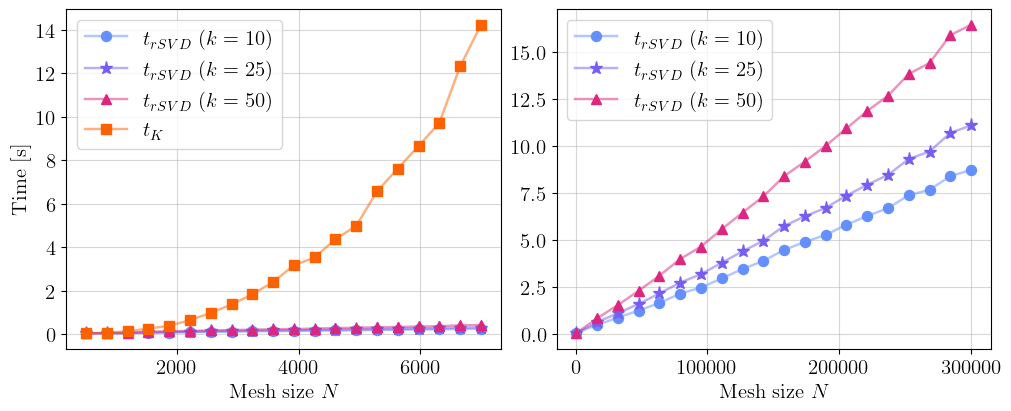

In [7]:
from utils.colors import C3, C5, M, MS
from utils.plotting import save_plot
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax, ax2 = axes

labels = ['$t_{rSVD}$ ($k=10$)',
          '$t_{rSVD}$ ($k=25$)',
          '$t_{rSVD}$ ($k=50$)',
          '$t_K$']
methods = ['mfrsvd k10',
           'mfrsvd k25',
           'mfrsvd k50',
           'assembly']

# Left plot
for i, method in enumerate(methods):
    ax.plot(median.N, median[method], M[i], ms=MS[i] * 1.2, c=C5[i], lw=1.75)
    ax.plot(median.N, median[method], c=C5[i], lw=1.75, alpha=.5, label=labels[i])

    if method != 'assembly':
        ax2.plot(median2.N, median2[method], M[i], ms=MS[i] * 1.2, c=C5[i], lw=1.75)
        ax2.plot(median2.N, median2[method], c=C5[i], lw=1.75, alpha=.5, label=labels[i])


# Custom labels
handles, labs = [], []
for i, method in enumerate(labels):
    legend_line = Line2D([0], [0], color=C5[i], linewidth=1.75, alpha=0.5)
    legend_marker = Line2D([0], [0], color=C5[i], marker=M[i], markersize=MS[i] * 1.2, linestyle='None')
    handles.append((legend_line, legend_marker))
    labs.append(method)



ax.grid(True, alpha=0.5)
ax2.grid(True, alpha=0.5)
ax.set_xlabel("Mesh size $N$")
ax2.set_xlabel("Mesh size $N$")
ax.set_ylabel("Time [s]")
ax.legend(handles=handles, labels=labels)
ax2.legend(handles=handles[:3], labels=labels[:3])
save_plot("rsvd_computational_time_comp")
plt.show()

In [8]:
repeat = 5
N_range = np.array([1000, 5000, 10000, 20000])

df = experiment(N_range, k_list, repeat=repeat)
median = df.groupby(['N']).median().reset_index().drop(columns='r')

[##############################] 20/20 [N=20,000]


In [9]:
k1, k2, k3 = k_list
for N in N_range:
    data = median[median.N == N]
    t = data['assembly'].values[0]
    print(
        f"{int(N):>5} & "
        f"{t / data[f'mfrsvd k{k1}'].values[0]:.1f} & "
        f"{t / data[f'mfrsvd k{k2}'].values[0]:.1f} & "
        f"{t / data[f'mfrsvd k{k3}'].values[0]:.1f} & "
        f"{t:.4} \\\\"
    )

 1000 & 3.7 & 3.7 & 2.6 & 0.1595 \\
 5000 & 32.8 & 26.6 & 18.6 & 5.381 \\
10000 & 117.9 & 92.1 & 67.6 & 36.1 \\
20000 & 479.1 & 377.8 & 276.5 & 260.6 \\
